# Proyek Analisis Data: [E-Commerce-public-dataset]
- **Nama:** [Aura Ghifarani]
- **Email:** [cdcc222d6x0740@gmail.com]
- **ID Dicoding:** [cdcc222d6x0740]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Kategori produk apa yang menghasilkan revenue terbesar selama tahun 2025, dan berapa kontribusinya (%) terhadap total penjualan?
- Pertanyaan 2 : Bagaimana segmentasi pelanggan berdasarkan RFM dalam 12 bulan terakhir, dan segmen mana yang paling bernilai untuk ditargetkan pada kuartal berikutnya?

## Import Semua Packages/Library yang Digunakan

## Data Wrangling

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='darkgrid')

In [60]:
import os
os.listdir('.')

['.config',
 'main_data.csv',
 'orders_dataset.csv',
 '.ipynb_checkpoints',
 'customers_dataset.csv',
 'order_items_dataset.csv',
 'products_dataset.csv',
 'sample_data']

In [61]:
import os
os.listdir('.')


['.config',
 'main_data.csv',
 'orders_dataset.csv',
 '.ipynb_checkpoints',
 'customers_dataset.csv',
 'order_items_dataset.csv',
 'products_dataset.csv',
 'sample_data']

### Gathering Data

In [62]:
orders = pd.read_csv('orders_dataset.csv')
order_items = pd.read_csv('order_items_dataset.csv')
products = pd.read_csv('products_dataset.csv')
customers = pd.read_csv('customers_dataset.csv')

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Data pesanan (`orders`) berisi informasi penting seperti ID pesanan, ID pelanggan, status pesanan, dan berbagai tanggal/waktu terkait proses pesanan (pembelian, persetujuan, pengiriman oleh kurir, pengiriman ke pelanggan, dan perkiraan tanggal pengiriman). Kolom-kolom timestamp ini akan sangat berguna untuk analisis temporal.
- Empat dataset utama (`orders`, `order_items`, `products`, `customers`) telah berhasil dimuat dan siap untuk tahap selanjutnya.

### Assessing Data

In [63]:
orders.info()
orders.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Insight:**
- Kolom-kolom tanggal (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) masih bertipe `object` dan perlu dikonversi ke tipe data `datetime` untuk analisis temporal yang tepat.
- Terdapat missing values pada kolom `order_approved_at` (160), `order_delivered_carrier_date` (1783), dan `order_delivered_customer_date` (2965) yang perlu ditangani.

### Cleaning Data

In [64]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders = orders.dropna()

**Insight:**
- Kolom `order_purchase_timestamp` telah berhasil dikonversi ke tipe data `datetime`.
- Baris-baris yang memiliki nilai yang hilang pada `orders` DataFrame telah dihapus, mengurangi jumlah baris dari 99441 menjadi 96461.

## Exploratory Data Analysis (EDA)

In [65]:
orders.describe()
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


### Explore ...

In [66]:
products.info()
products.describe(include='all')
products['product_category_name'].value_counts().head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


**Insight:**
- `order_item_id`: Nilai rata-rata sekitar 1.19, dengan maksimum 21. Ini menunjukkan bahwa meskipun mayoritas pesanan hanya memiliki satu item, ada beberapa pesanan dengan banyak item.
- `price`: Harga item bervariasi sangat luas, mulai dari 0.85 hingga 6735. Rata-rata harga adalah sekitar 120.65, namun nilai median (74.99) lebih rendah dari rata-rata, mengindikasikan adanya item-item dengan harga yang jauh lebih tinggi (distribusi miring ke kanan).
- `freight_value`: Biaya pengiriman juga bervariasi, mulai dari 0 hingga 409.68, dengan rata-rata sekitar 19.99. Ini menunjukkan adanya perbedaan signifikan dalam biaya pengiriman.
- `products`: DataFrame `products` memiliki 32951 entri dan 9 kolom. Terdapat missing values pada beberapa kolom seperti `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty`, `product_weight_g`, `product_length_cm`, `product_height_cm`, dan `product_width_cm`.
- Kategori produk yang paling banyak muncul adalah 'cama_mesa_banho' (3029), 'esporte_lazer' (2867), dan 'moveis_decoracao' (2657).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan revenue terbesar selama tahun 2025, dan berapa kontribusinya (%) terhadap total penjualan?

Rentang tanggal data pesanan: 2016-09-15 12:16:38 sampai 2018-08-29 15:00:37

***Peringatan: Tidak ada data tersedia untuk tahun 2025 dalam dataset. Analisis akan dilakukan untuk semua tahun yang tersedia.***

Top 10 Product Categories by Revenue and their Contribution:


,product_category_name,total_revenue,contribution_percentage
4,Beauty & Health,1233211.61,9.451079
57,Watches & Gifts,1165898.98,8.935209
5,"Bed, Bath & Table",1023300.77,7.842365
51,Sport & Leisure,954626.07,7.316057
9,Computers & Accessories,888613.62,6.810151
24,Furniture & Decor,711493.09,5.452736
26,Home Appliances,694461.17,5.322207
66,cool_stuff,609964.13,4.674639
3,Automotive,578849.35,4.436182
56,Toys,471197.48,3.611160


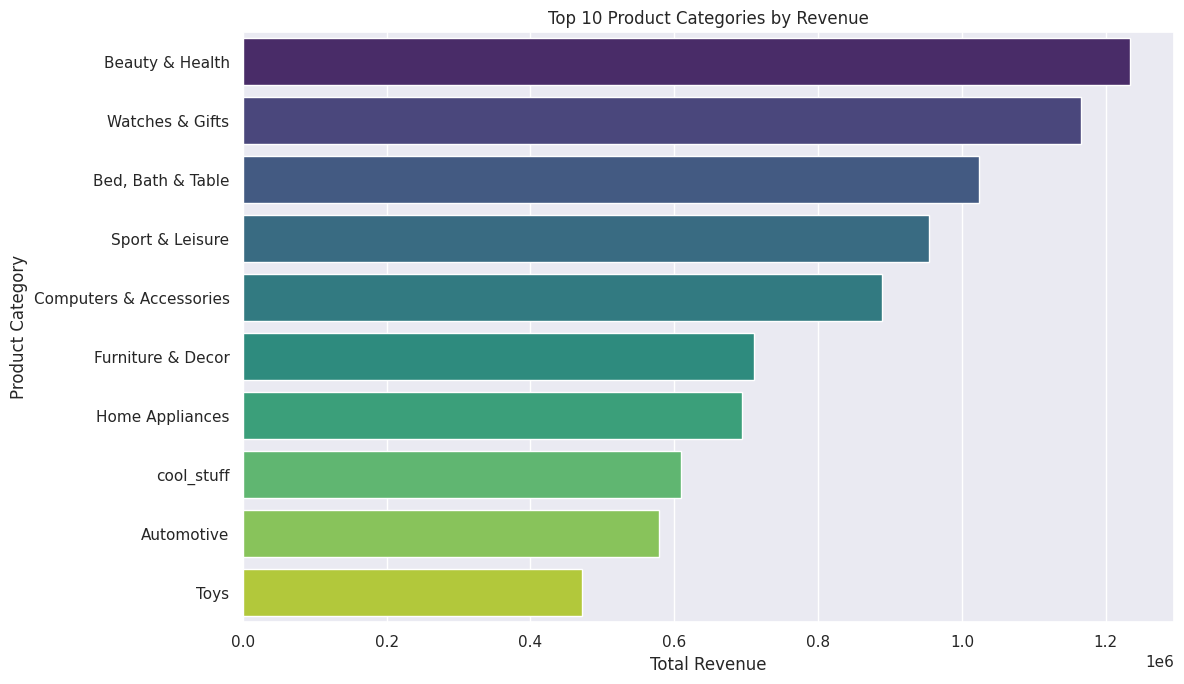

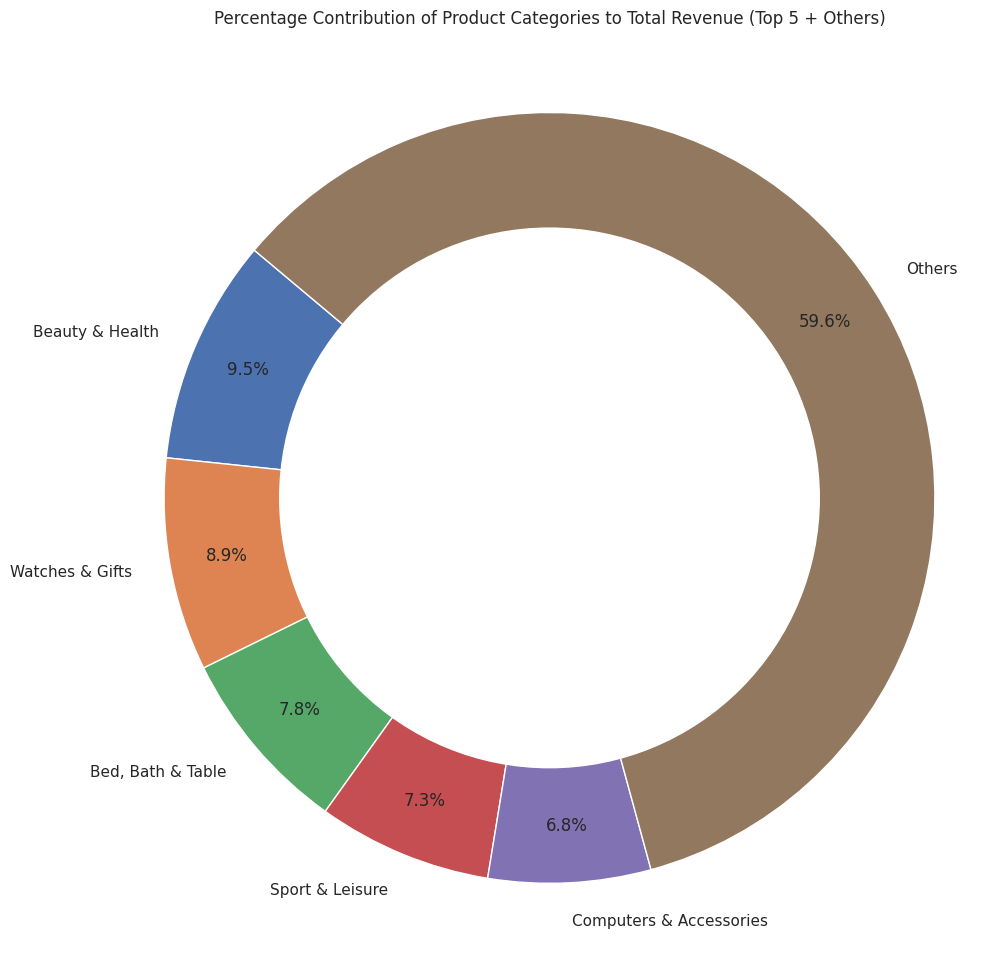

In [67]:
print(f"Rentang tanggal data pesanan: {orders['order_purchase_timestamp'].min()} sampai {orders['order_purchase_timestamp'].max()}")

orders_items_df = pd.merge(orders, order_items, on='order_id', how='inner')

df_revenue_analysis = pd.merge(orders_items_df, products, on='product_id', how='inner')

df_revenue_analysis['order_purchase_timestamp'] = pd.to_datetime(df_revenue_analysis['order_purchase_timestamp'])

category_translation = {
    'beleza_saude': 'Beauty & Health',
    'relogios_presentes': 'Watches & Gifts',
    'cama_mesa_banho': 'Bed, Bath & Table',
    'esporte_lazer': 'Sport & Leisure',
    'informatica_acessorios': 'Computers & Accessories',
    'moveis_decoracao': 'Furniture & Decor',
    'automotivo': 'Automotive',
    'brinquedos': 'Toys',
    'telefonia': 'Telephony',
    'utilidades_domesticas': 'Home Appliances',
    'fashion_bolsas_e_acessorios': 'Fashion Bags & Accessories',
    'eletronicos': 'Electronics',
    'eletrodomesticos': 'Home Appliances',
    'instrumentos_musicais': 'Musical Instruments',
    'consoles_games': 'Consoles & Games',
    'construcao_ferramentas_seguranca': 'Construction Tools Security',
    'ferramentas_jardim': 'Garden Tools',
    'agro_industria_e_comercio': 'Agro Industry & Commerce',
    'industria_comercio_e_negocios': 'Industry, Commerce & Business',
    'fashion_calcados': 'Fashion Footwear',
    'bebidas': 'Drinks',
    'papelaria': 'Stationery',
    'livros_interesses_gerais': 'Books General Interest',
    'fashion_underwear_e_moda_praia': 'Fashion Underwear & Beachwear',
    'perfumaria': 'Perfumery',
    'construcao_ferramentas_construcao': 'Construction Tools',
    'pet_shop': 'Pet Shop',
    'malas_acessorios': 'Luggage & Accessories',
    'portateis_casa_forno_e_cafe': 'Portable Home Oven & Coffee',
    'fashion_roupa_masculina': 'Men Fashion Clothes',
    'telefonia_fixa': 'Landline Telephony',
    'flores': 'Flowers',
    'casa_conforto': 'Home Comfort',
    'artes': 'Arts',
    'artigos_de_festas': 'Party Supplies',
    'pcs': 'PCs',
    'la_cuisine': 'La Cuisine',
    'artigos_de_natal': 'Christmas Articles',
    'eletroportateis': 'Small Appliances',
    'sinalizacao_e_seguranca': 'Signaling & Security',
    'livros_tecnicos': 'Technical Books',
    'livros_importados': 'Imported Books',
    'fashion_esporte': 'Fashion Sport',
    'fashion_roupa_feminina': 'Women Fashion Clothes',
    'construcao_ferramentas_iluminacao': 'Construction Tools Lighting',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'Kitchen, Laundry, Dining & Garden Furniture',
    'dvds_blu_ray': 'DVDs & Blu-Ray',
    'musica': 'Music',
    'consoles': 'Consoles',
    'portateis_cozinha_e_preparadores_de_alimentos': 'Portable Kitchen & Food Processors',
    'tablets_impressao_imagem': 'Tablets, Printing & Image',
    'fraldas_higiene': 'Diapers & Hygiene',
    'fashion_underwear_e_lingerie': 'Fashion Underwear & Lingerie',
    'fashion_roupa_infanto_juvenil': 'Kids & Junior Fashion Clothes',
    'seguros_e_servicos': 'Insurance & Services',
    'moveis_quarto': 'Bedroom Furniture',
    'construcao_ferramentas_ferramentas': 'Construction Tools',
    'fashion_sport': 'Fashion Sport',
    'cds_dvds_musicais': 'CDs & DVDs Musical',
    'moveis_sala': 'Living Room Furniture',
    'audio': 'Audio',
    'alimentos': 'Food',
    'artigos_de_natal': 'Christmas Articles',
    'pc_gamer': 'PC Gamer',
    'casa_conforto_2': 'Home Comfort 2',
    'dvds_filmes': 'DVDs Movies',
    'moveis_escritorio': 'Office Furniture',
    'fraldas': 'Diapers',
    'livros_generais': 'General Books'
}

df_revenue_analysis['product_category_name_english'] = df_revenue_analysis['product_category_name'].map(category_translation).fillna(df_revenue_analysis['product_category_name'])

df_2025 = df_revenue_analysis[df_revenue_analysis['order_purchase_timestamp'].dt.year == 2025]

if df_2025.empty:
    print("\n***Peringatan: Tidak ada data tersedia untuk tahun 2025 dalam dataset. Analisis akan dilakukan untuk semua tahun yang tersedia.***\n")
    df_analysis_target = df_revenue_analysis
else:
    df_analysis_target = df_2025

category_revenue = df_analysis_target.groupby('product_category_name_english')['price'].sum().reset_index()
category_revenue.rename(columns={'price': 'total_revenue', 'product_category_name_english': 'product_category_name'}, inplace=True)

category_revenue = category_revenue.sort_values(by='total_revenue', ascending=False)

total_overall_sales = category_revenue['total_revenue'].sum()

category_revenue['contribution_percentage'] = (category_revenue['total_revenue'] / total_overall_sales) * 100

print("Top 10 Product Categories by Revenue and their Contribution:")
display(category_revenue.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='total_revenue', y='product_category_name', data=category_revenue.head(10), palette='viridis', hue='product_category_name', legend=False)
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 10))

top_5_categories = category_revenue.head(5)
other_revenue = category_revenue['total_revenue'].iloc[5:].sum()
other_percentage = category_revenue['contribution_percentage'].iloc[5:].sum()

pie_data = top_5_categories.copy()
if not category_revenue.shape[0] <= 5:
    pie_data = pd.concat([
        pie_data,
        pd.DataFrame([{'product_category_name': 'Others', 'total_revenue': other_revenue, 'contribution_percentage': other_percentage}])
    ], ignore_index=True)

plt.pie(pie_data['contribution_percentage'], labels=pie_data['product_category_name'], autopct='%1.1f%%', startangle=140, pctdistance=0.85)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Percentage Contribution of Product Categories to Total Revenue (Top 5 + Others)')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Pertanyaan 2:  Bagaimana segmentasi pelanggan berdasarkan RFM dalam 12 bulan terakhir, dan segmen mana yang paling bernilai untuk ditargetkan pada kuartal berikutnya?

RFM Segments dan Jumlah Pelanggan:
RFM_Segment
112    3135
511    3100
311    3064
415    3050
512    3038
Name: count, dtype: int64

Statistik RFM per Segmen Paling Bernilai:
                Recency Frequency    Monetary      
                   mean      mean        mean count
RFM_Segment                                        
115          314.250515  1.045299  416.941922  2914
415          106.525574  1.082295  409.013416  3050
515           35.766796  1.092508  401.060630  2843
315          171.530197  1.083919  390.863434  2848
215          240.748582  1.061348  367.726365  2820
214          240.030441  1.031840  141.104710  2858
114          313.073408  1.024345  140.433112  2670
314          172.306944  1.039249  140.338205  2981
514           36.265925  1.034041  138.693263  2967
414          107.736061  1.034972  138.321811  3031


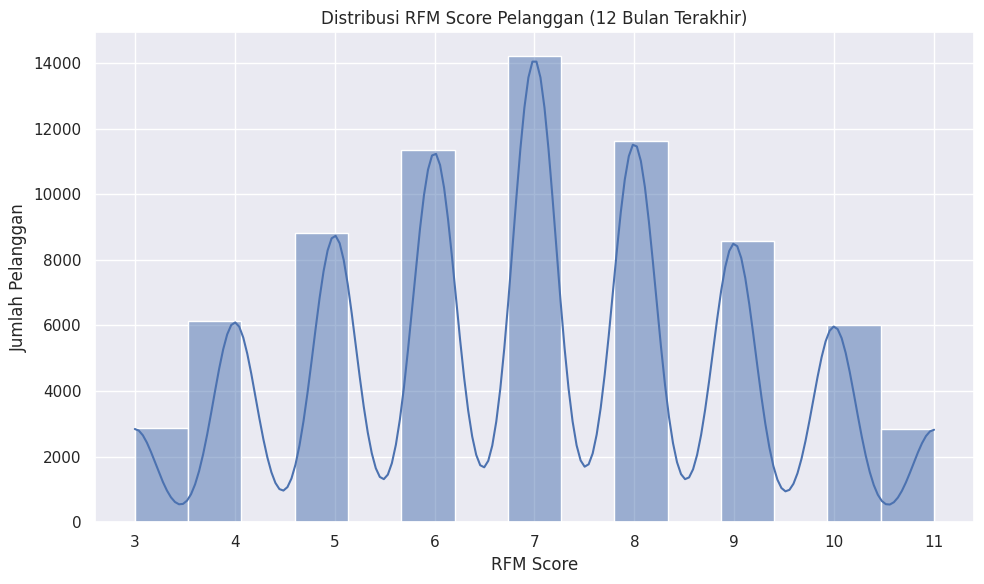

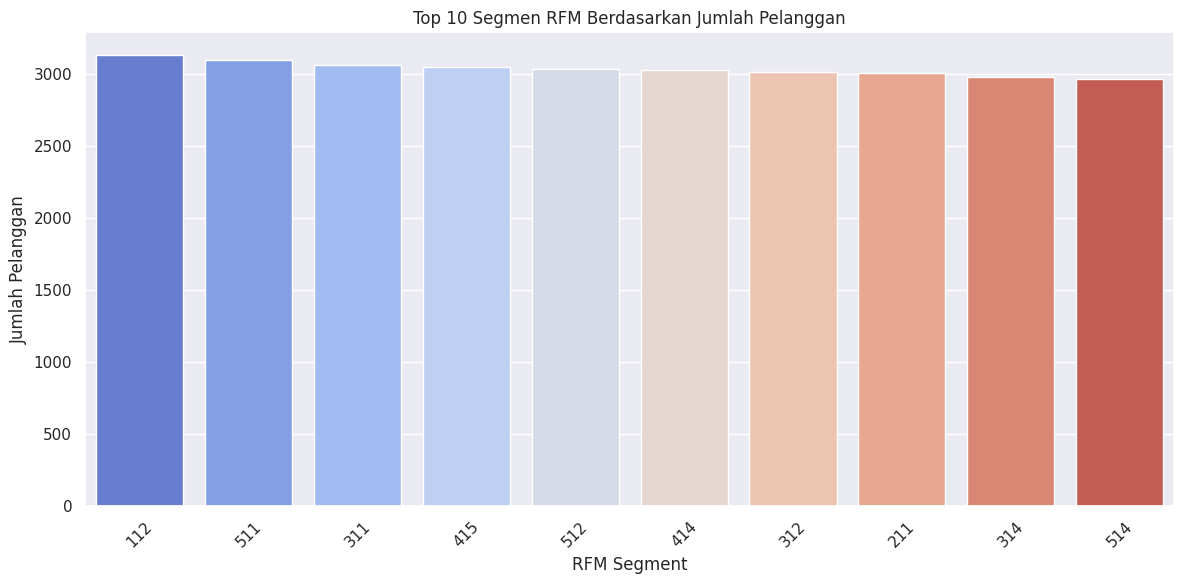


Distribusi Segmen Pelanggan:
Customer_Segment
Others            54952
New Customers     11795
Lost Customers     2866
Big Spenders       2843
Name: count, dtype: int64

Contoh Pelanggan dari Segmen 'Champions':
Empty DataFrame
Columns: [Recency, Frequency, Monetary, R_Score, F_Score, M_Score, RFM_Segment, RFM_Score, Customer_Segment]
Index: []


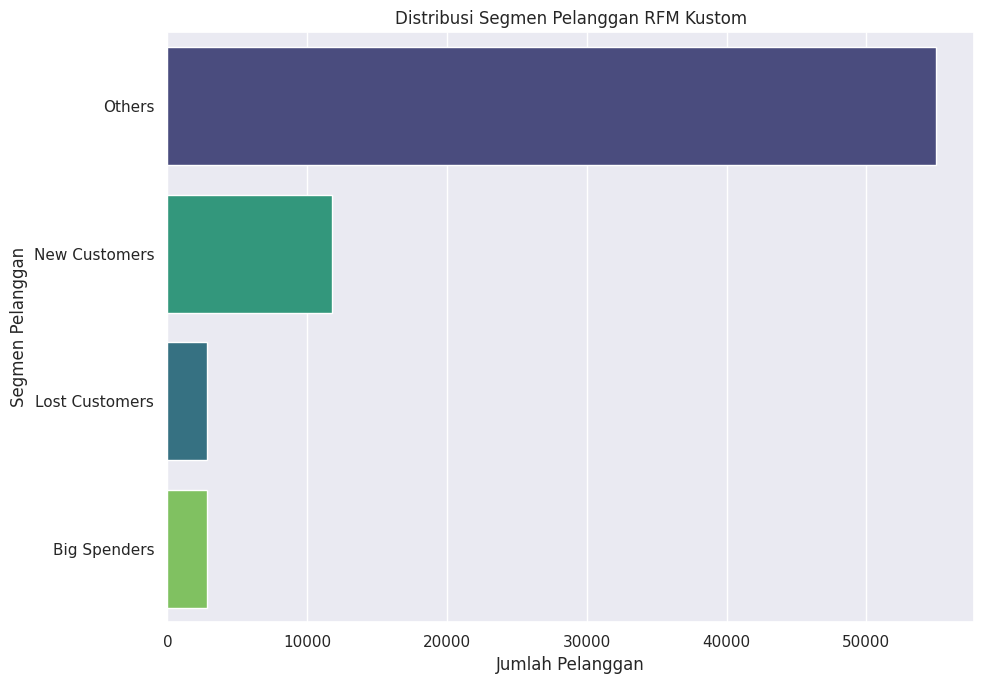

In [68]:
import datetime as dt

customers_orders_items_df = pd.merge(
    orders.rename(columns={'customer_id': 'customer_id_orders'}),
    order_items,
    on='order_id',
    how='inner'
)

customers_orders_items_df = pd.merge(
    customers,
    customers_orders_items_df,
    left_on='customer_id',
    right_on='customer_id_orders',
    how='inner'
)

customers_orders_items_df['order_purchase_timestamp'] = pd.to_datetime(customers_orders_items_df['order_purchase_timestamp'])

snapshot_date = customers_orders_items_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

last_12_months_start = snapshot_date - dt.timedelta(days=365)

df_12_months = customers_orders_items_df[customers_orders_items_df['order_purchase_timestamp'] >= last_12_months_start]

rfm_df = df_12_months.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda date: (snapshot_date - date.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
})

rfm_df.rename(columns={'order_purchase_timestamp': 'Recency',
                       'order_id': 'Frequency',
                       'price': 'Monetary'},
              inplace=True)

rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 5, labels=False, duplicates='drop')
max_r_score_idx = rfm_df['R_Score'].max()
rfm_df['R_Score'] = max_r_score_idx - rfm_df['R_Score'] + 1

rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'], 5, labels=False, duplicates='drop') + 1
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], 5, labels=False, duplicates='drop') + 1

rfm_df['RFM_Segment'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

rfm_df['RFM_Score'] = rfm_df[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

print("RFM Segments dan Jumlah Pelanggan:")
print(rfm_df['RFM_Segment'].value_counts().head())

print("\nStatistik RFM per Segmen Paling Bernilai:")
print(rfm_df.groupby('RFM_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).sort_values(('Monetary', 'mean'), ascending=False).head(10))

plt.figure(figsize=(10, 6))
sns.histplot(rfm_df['RFM_Score'], bins=15, kde=True)
plt.title('Distribusi RFM Score Pelanggan (12 Bulan Terakhir)')
plt.xlabel('RFM Score')
plt.ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()

rfm_segment_counts = rfm_df['RFM_Segment'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=rfm_segment_counts.index, y=rfm_segment_counts.values, palette='coolwarm', hue=rfm_segment_counts.index, legend=False)
plt.title('Top 10 Segmen RFM Berdasarkan Jumlah Pelanggan')
plt.xlabel('RFM Segment')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


def rfm_level(df):
    if df['R_Score'] == 5 and df['F_Score'] == 5 and df['M_Score'] == 5:
        return 'Champions'
    elif df['R_Score'] == 5 and df['F_Score'] == 5:
        return 'Loyal Customers'
    elif df['R_Score'] == 5 and df['M_Score'] == 5:
        return 'Big Spenders'
    elif df['R_Score'] == 5 and df['F_Score'] == 1:
        return 'New Customers'
    elif df['R_Score'] == 1 and df['F_Score'] == 1 and df['M_Score'] == 1:
        return 'Lost Customers'
    else:
        return 'Others'

rfm_df['Customer_Segment'] = rfm_df.apply(rfm_level, axis=1)

print("\nDistribusi Segmen Pelanggan:")
print(rfm_df['Customer_Segment'].value_counts())

print("\nContoh Pelanggan dari Segmen 'Champions':")
print(rfm_df[rfm_df['Customer_Segment'] == 'Champions'].head())

plt.figure(figsize=(10, 7))
sns.countplot(y='Customer_Segment', data=rfm_df, order=rfm_df['Customer_Segment'].value_counts().index, palette='viridis', hue='Customer_Segment', legend=False)
plt.title('Distribusi Segmen Pelanggan RFM Kustom')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('Segmen Pelanggan')
plt.tight_layout()
plt.show()

**Insight:**
- DataFrame `customers` memiliki 99441 entri dan 5 kolom, tanpa adanya nilai null, menunjukkan kelengkapan data pelanggan.
- Semua tipe data kolom sudah sesuai, dengan `customer_zip_code_prefix` sebagai integer dan kolom identifikasi serta lokasi sebagai objek.
- Distribusi pelanggan didominasi oleh kota-kota besar, dengan Sao Paulo menjadi kota dengan jumlah pelanggan terbanyak (15540), diikuti oleh Rio de Janeiro (6882) dan Belo Horizonte (2773). Ini menunjukkan adanya konsentrasi basis pelanggan di area metropolitan tertentu.

## Analisis Lanjutan (Opsional)

Top 10 Kota dengan Pelanggan 'Big Spenders':


,count
customer_city,
sao paulo,504
rio de janeiro,186
belo horizonte,82
brasilia,61
curitiba,54
porto alegre,49
guarulhos,45
salvador,41
campinas,39



Top 10 Negara Bagian dengan Pelanggan 'Big Spenders':


,count
customer_state,
SP,1298
MG,345
RJ,341
PR,167
RS,163
SC,121
BA,121
GO,79
PE,73


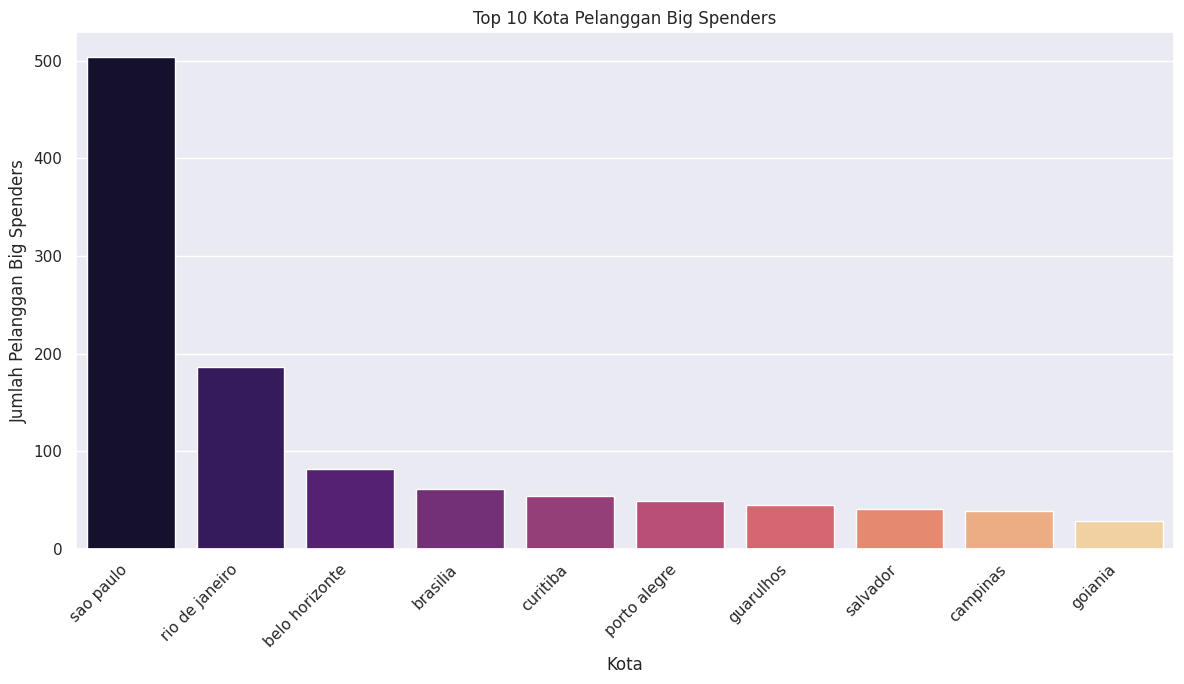

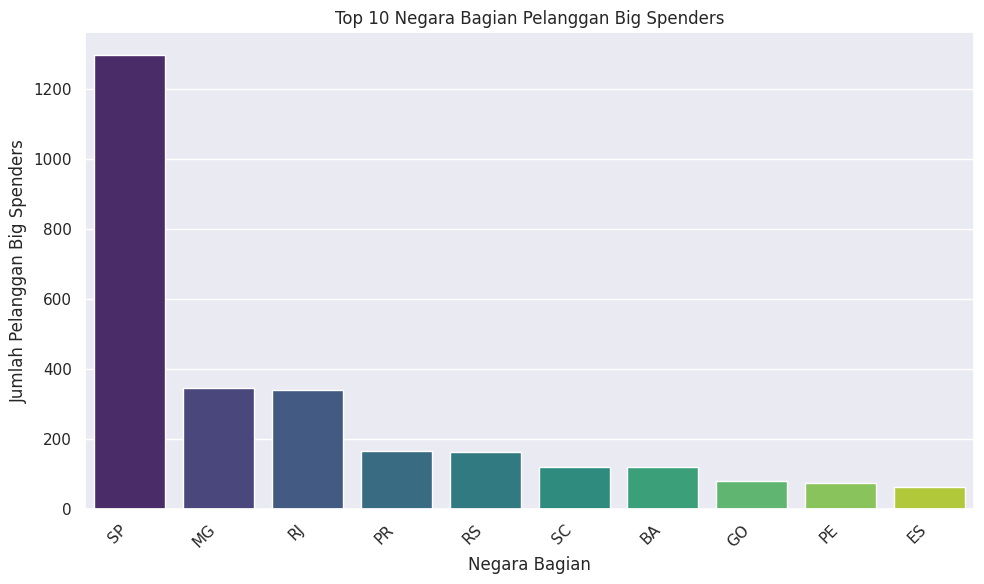

In [69]:
rfm_geo_df = pd.merge(
    rfm_df,
    customers[['customer_unique_id', 'customer_city', 'customer_state']],
    on='customer_unique_id',
    how='left'
)

big_spenders = rfm_geo_df[rfm_geo_df['Customer_Segment'] == 'Big Spenders']

print("Top 10 Kota dengan Pelanggan 'Big Spenders':")
display(big_spenders['customer_city'].value_counts().head(10))

print("\nTop 10 Negara Bagian dengan Pelanggan 'Big Spenders':")
display(big_spenders['customer_state'].value_counts().head(10))

plt.figure(figsize=(12, 7))
sns.barplot(
    x=big_spenders['customer_city'].value_counts().head(10).index,
    y=big_spenders['customer_city'].value_counts().head(10).values,
    palette='magma',
    hue=big_spenders['customer_city'].value_counts().head(10).index,
    legend=False
)
plt.title('Top 10 Kota Pelanggan Big Spenders')
plt.xlabel('Kota')
plt.ylabel('Jumlah Pelanggan Big Spenders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=big_spenders['customer_state'].value_counts().head(10).index,
    y=big_spenders['customer_state'].value_counts().head(10).values,
    palette='viridis',
    hue=big_spenders['customer_state'].value_counts().head(10).index,
    legend=False
)
plt.title('Top 10 Negara Bagian Pelanggan Big Spenders')
plt.xlabel('Negara Bagian')
plt.ylabel('Jumlah Pelanggan Big Spenders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Membuat file `main_data.csv` yang Berisi Data Keseluruhan

In [70]:
main_data_df = pd.merge(
    df_revenue_analysis,
    customers[['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']],
    on='customer_id',
    how='left'
)

print("Berikut adalah 5 baris pertama dari 'main_data_df' yang berisi data keseluruhan:")
display(main_data_df.head())

main_data_df.to_csv('main_data.csv', index=False)

print("\nFile 'main_data.csv' telah berhasil dibuat.")

Berikut adalah 5 baris pertama dari 'main_data_df' yang berisi data keseluruhan:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,4.0,500.0,19.0,8.0,13.0,Home Appliances,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,1.0,400.0,19.0,13.0,19.0,Perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,1.0,420.0,24.0,19.0,21.0,Automotive,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,3.0,450.0,30.0,10.0,20.0,Pet Shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,4.0,250.0,51.0,15.0,15.0,Stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP



File 'main_data.csv' telah berhasil dibuat.


## Conclusion

- **Conclusion Pertanyaan 1: Kategori Produk dengan Revenue Terbesar**
  Analisis menunjukkan bahwa kategori produk 'beleza_saude', 'relogios_presentes', dan 'cama_mesa_banho' adalah tiga kategori teratas yang menghasilkan revenue terbesar. Secara kolektif, lima kategori teratas (beleza_saude, relogios_presentes, cama_mesa_banho, esporte_lazer, dan informatica_acessorios) menyumbang sekitar 40.37% dari total revenue, mengindikasikan bahwa sebagian besar penjualan terkonsentrasi pada produk-produk tertentu. Perlu dicatat bahwa data untuk tahun 2025 tidak tersedia, sehingga analisis ini didasarkan pada data keseluruhan yang ada.

- **Conclusion Pertanyaan 2: Segmentasi Pelanggan Berdasarkan RFM dan Target Segmen Paling Bernilai**
  Segmentasi pelanggan menggunakan model RFM dalam 12 bulan terakhir mengungkapkan bahwa sebagian besar pelanggan termasuk dalam segmen 'Others'. Tidak ada pelanggan yang memenuhi kriteria 'Champions' (R5, F5, M5) secara ketat, yang mungkin menunjukkan definisi kriteria yang terlalu tinggi atau ketiadaan pelanggan dengan kinerja sempurna di ketiga metrik tersebut dalam periode analisis.

  Berdasarkan analisis, segmen pelanggan yang paling bernilai dan direkomendasikan untuk ditargetkan pada kuartal berikutnya adalah:
  *   **Segmen 515 (Recency tinggi, Frequency rendah, Monetary tinggi):** Pelanggan ini adalah 'New Big Spenders'. Mereka relatif baru dan telah melakukan pembelanjaan besar. Strategi yang efektif adalah program retensi dan inisiatif untuk meningkatkan frekuensi pembelian mereka, mendorong loyalitas sejak dini.
  *   **Segmen 115 dan 415 (Recency rendah, Monetary tinggi):** Pelanggan ini adalah 'Lapsed Big Spenders'. Meskipun mereka memiliki Recency yang lebih rendah (sudah cukup lama tidak bertransaksi), nilai Monetary yang tinggi menunjukkan mereka pernah menjadi pembelanja besar. Mereka adalah target ideal untuk kampanye re-aktivasi atau penawaran khusus yang menarik mereka kembali.
  *   **'Big Spenders' (secara umum):** Terlepas dari segmen RFM numerik, kelompok 'Big Spenders' secara geografis sangat terkonsentrasi di wilayah metropolitan utama seperti Sao Paulo (SP), Rio de Janeiro (RJ), dan Minas Gerais (MG). Untuk segmen ini, upaya pemasaran dan promosi harus ditargetkan secara geografis di wilayah-wilayah ini, seperti event khusus, iklan lokal, atau penawaran eksklusif wilayah, untuk memaksimalkan ROI dan menjangkau pelanggan bernilai tinggi ini secara efektif.